In [1]:
import torch
from torch import nn
import gymnasium as gym
import ale_py
import cv2
from matplotlib import pyplot as plt
from collections import deque
import random
import copy

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
memory_capacity = 30000
num_episodes = 10000
epsilon = lambda frames: max(0.1, 1.0 - frames / (2 * 1e5))
max_episode_steps = 10000
learning_rate = 1e-4
minibatch_size = 64
discount_factor = 0.99
target_update_freq = 2000

In [4]:
gym.register_envs(ale_py)
env = gym.make("ALE/Breakout-v5", render_mode=None, max_episode_steps=max_episode_steps)

In [5]:
def preprocess_image(image, crop_top=20):
    image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) / 255.0
    image = cv2.resize(image, (84, 110))
    return image[crop_top:crop_top+84, :] # 84x84 grayscale

(210, 160, 3)


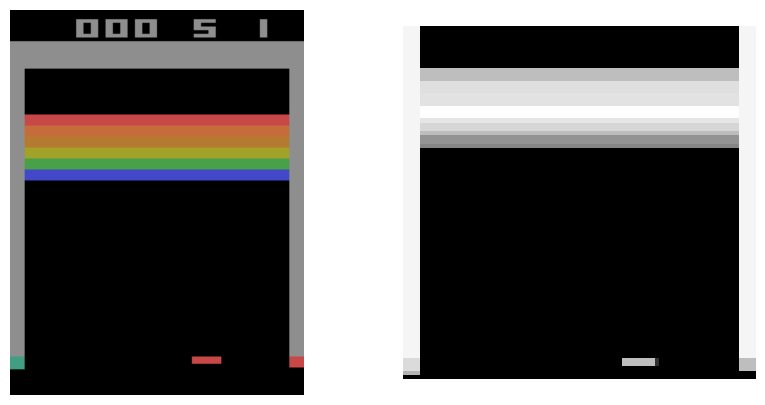

In [6]:
obs, info = env.reset()
print(obs.shape)

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.imshow(obs)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(preprocess_image(obs), cmap='gray')
plt.axis('off')

plt.show()

In [7]:
class DQN(nn.Module):
    def __init__(self, num_actions=4): # inp shape: (b, 4, 84, 84)
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(4, 16, kernel_size=8, stride=4),  # 84x84 - 20x20
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2),  # 20x20 - 9x9
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 9 * 9, 256),
            nn.ReLU(),
            nn.Linear(256, num_actions)
        )
        
    def forward(self, x):
        return self.layers(x)

In [8]:
model = DQN().to(device)
target_model = copy.deepcopy(model).to(device) # for stability

print(model)

DQN(
  (layers): Sequential(
    (0): Conv2d(4, 16, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=2592, out_features=256, bias=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [9]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [10]:
replay_memory = deque(maxlen=memory_capacity)

In [ ]:
total_frames = 0

model.train()
target_model.eval()


for episode in range(num_episodes):
    episode_reward = 0
    episode_frames = 0

    obs, info = env.reset()
    frame_stack = deque([preprocess_image(obs)] * 4, maxlen=4)

    done = False
    debug = False

    while not done:
        if random.random() < epsilon(total_frames):
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                inp = torch.tensor(frame_stack, dtype=torch.float32).unsqueeze(0).to(device)  # add batch dim
                action = torch.argmax(model(inp), dim=1).item()

        obs, reward, terminated, truncated, info = env.step(action)
        reward -= 0.01  # general time penalty

        episode_reward += reward
        episode_frames += 1
        total_frames += 1
        done = terminated or truncated

        old_frame_stack = torch.tensor(frame_stack, dtype=torch.float32)
        frame_stack.append(preprocess_image(obs))
        replay_memory.append((old_frame_stack, action, reward, torch.tensor(frame_stack, dtype=torch.float32), done))

        if len(replay_memory) >= minibatch_size and total_frames % 4 == 0:
            batch = random.sample(replay_memory, minibatch_size)
            old_frame_stack, actions, rewards, new_frame_stack, dones = zip(*batch)

            old_frame_stack = torch.stack(old_frame_stack).to(device)
            actions = torch.tensor(actions, dtype=torch.long).to(device)
            rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
            new_frame_stack = torch.stack(new_frame_stack).to(device)
            dones = torch.tensor(dones, dtype=torch.float32).to(device)

            with torch.no_grad():
                targets = (
                    rewards
                    + (1 - dones)
                    * discount_factor
                    * torch.max(target_model(new_frame_stack), dim=1).values
                )
            
            preds = model(old_frame_stack).gather(1, actions.unsqueeze(1)).squeeze(1)

            loss = loss_fn(preds, targets)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
            if total_frames % target_update_freq == 0:
                target_model.load_state_dict(model.state_dict())
                print(f"Updated target network at frame {total_frames}")
            
    if episode % 20 == 0:
        torch.save(model.state_dict(), f"models/dqn_model_episode_{episode}.pth")

    print(f"Episode {episode + 1}: Total Reward: {episode_reward:.3f}  Average Reward: {episode_reward / (episode_frames + 1):.7f} Frames: {episode_frames} Epsilon: {epsilon(total_frames):.3f}")

C:\Users\Neelesh Mishra\AppData\Local\Temp\ipykernel_2248\1088370027.py:33: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  old_frame_stack = torch.tensor(frame_stack, dtype=torch.float32)


Episode 1: Total Reward: -0.720  Average Reward: -0.0041618 Frames: 172 Epsilon: 0.999
Episode 2: Total Reward: -1.290  Average Reward: -0.0099231 Frames: 129 Epsilon: 0.998
Episode 3: Total Reward: -1.350  Average Reward: -0.0099265 Frames: 135 Epsilon: 0.998
Episode 4: Total Reward: 0.570  Average Reward: 0.0023361 Frames: 243 Epsilon: 0.997
Episode 5: Total Reward: -1.500  Average Reward: -0.0099338 Frames: 150 Epsilon: 0.996
Episode 6: Total Reward: -1.310  Average Reward: -0.0099242 Frames: 131 Epsilon: 0.995
Episode 7: Total Reward: -0.590  Average Reward: -0.0036875 Frames: 159 Epsilon: 0.994
Episode 8: Total Reward: -0.130  Average Reward: -0.0006075 Frames: 213 Epsilon: 0.993
Episode 9: Total Reward: 0.980  Average Reward: 0.0032343 Frames: 302 Epsilon: 0.992
Episode 10: Total Reward: -0.770  Average Reward: -0.0043258 Frames: 177 Epsilon: 0.991
Updated target network at frame 2000
Episode 11: Total Reward: -0.060  Average Reward: -0.0002899 Frames: 206 Epsilon: 0.990
Episode 